# Logical Relationship Testing

Testing logical relationships within a structure set.


## Logical Relationships

Within a set of structures, transitive relationships can result in **Logical** 
relationships, which exists out of necessity due to other relationships in the 
structure set. The simplest example is one where **A** *Contains* **B** and 
**B** *Contains* **C**, therefore the relationship **A** *Contains* **C** is **Logical** 
since it is a requirement of the other two relationships.  

**Logical** relationships can also be chained further. For example, 
if **C** *Contains* **D**, the relationships **A** *Contains* **D** and 
**B** *Contains* **D** are both **Logical**.


### Implied relationships
Identifying **Logical** relationships is complicated by the fact that some 
relationships **Imply** other ones.  For example, *Partitioned* is not 
transitive, but it **Implies** the *Contains* relationship, so the following 
scenario is possible: If **A** *Is Partitioned by* **B** and **B** *Contains* **C** the 
relationship **A** *Contains* **C** is **Logical**.  
However, If **A** *Is Partitioned by* **B** and **B** *Is Partitioned by* **C** either the 
relationship **A** *Contains* **C** or the relationship **A** *Is Partitioned by* **C** are 
possible, so a **Logical** relationship does not exist.


#### Example: Identifying Logical *Contains* Relationships

To identify **Logical** *Contains* relationships, one must construct a directed 
graph of the structure relations where the edges are all the *Contains* 
relationships in the structure set and all **Implied** *Contains* 
relationships (*Partitioned*) in the structure set. Next, for each *Contains* 
relationship, check for an alternate path between the two structures. Next, 
eliminate any path that is not composed *entirely* of **Implied** *Contains* 
relationships. If an alternate path exists, then the relationship is 
**Logical**.


### The special case of Equals
The *Equals* relationship is a special case since it is both symmetric and 
transitive. Therefore, if A *Equals* B and B *Contains* C, then A *Contains* C is 
**Logical**. Similarly, if A *Equals* B and B *Is Partitioned by* C, then A 
*Is Partitioned by* C is **Logical**. This can be extended to chains of
*Equals* relationships of any length.

### Logical Relationship Identification Implementation
I want to use graph analysis make the structure_set.calculate_logical_flags 
method apply this logic to identify **Logical** relationships within a 
structure set.
This will involve:

- Transitivity analysis (e.g., A contains B, B contains C)
- Connected component analysis
- Path analysis through relationship graph
- Pattern matching for specific relationship combinations


### Relationship Properties

The spatial relationship have the following properties:

**Symmetric** 
> A relation is **symmetric** if $aRb \iff bRa$ for all $a$ and $b$. 
>
> - For example, if A *Equals* B then B *Equals* A.
>
> The **symmetric** relations are:
>
> - Equals, Overlaps, Disjoint, Borders

**Transitive** 

> A relation is **transitive** if whenever, $aRb$ and $bRc$ then $aRc$. 
>
> - For example, if A *Contains* B and B *Contains* C, then A *Contains* C.
>
> The **transitive** relations are:
>
> - Equals, Contains, Shelters, Surrounds. 



|Relationship|Symmetric|Transitive|Complement|
|------------|---------|----------|----------|
|Disjoint    |Yes      |No        |Disjoint  |
|Shelters    |No       |Yes       |Sheltered |
|Surrounds   |No       |Yes       |Enclosed  |
|Borders     |Yes      |No        |Borders   |
|Confines    |No       |No        |Confined  |
|Contains    |No       |Yes       |Within    |
|Equals      |Yes      |Yes       |Equals    |
|Partitioned |No       |No        |Partitions|
|Overlaps    |Yes      |No        |Overlaps  |


### Tests to verify correct identification of **Logical** relationships.

#### Is Logical
1. A *Contains* B and B *Contains* C. 
> Verify that the relationship A *Contains* C is **Logical**.

2. A *Contains* B and B *Contains* C and C *Contains* D.
> Verify that the relationships A *Contains* D and B *Contains* D are both **Logical**.

3. A *Is Partitioned by* B and B *Contains* C.
> Verify that the relationship A *Contains* C is **Logical**.  

4. A *Is Partitioned by* B and B *Is Partitioned by* C.
> Verify that A *Contains* C is not **Logical**.  

- Also for *Contains* and *Surrounds*

- Test for spacial case of *Equals*


#### Is Not Logical
5. A *Is Partitioned by* B and B *Is Partitioned by* C.
> Verify that the relationship A *Is Partitioned by* C is not **Logical**.  


5. A *Borders* B and B *Borders* C.
> Verify that the relationship A *Borders* C is not **Logical**.  


In [42]:
# Standard Libraries
import logging
from pprint import pprint

# Shared Packages
import shapely


# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from relations import *

In [2]:
%matplotlib inline

In [18]:
def get_status(structures):
    relation_status = {}
    edges = list(structures.relationship_graph.edges)
    for edge in edges:
        label = f'({edge[0]}, {edge[1]})'
        relation = structures.get_relationship(*edge)
        relation_type = relation.de27im.identify_relation()
        is_logical = relation.is_logical
        relation_status[label] = {
            'Relationship:': relation_type.label,
            'Is Logical:': is_logical
            }
    return relation_status


## Logical Relationship Tests

#### Embedded Spheres
- 3 nested spheres.


In [24]:
def embedded_spheres_example():
    slice_spacing = 1
    # Outside Sphere
    sphere12 = make_sphere(roi_num=1, radius=6, spacing=slice_spacing)
    sphere8 = make_sphere(roi_num=2, radius=4, spacing=slice_spacing)
    sphere6 = make_sphere(roi_num=3, radius=3, spacing=slice_spacing)

    # combine the contours
    slice_data = sphere12 + sphere8 + sphere6
    return slice_data


In [25]:
slice_data = embedded_spheres_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)

INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculating logical flags for relationships


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'}}


**Relationship (1,3) should be _Logical_**

In [26]:
def multi_embedded_spheres_example():
    slice_spacing = 1
    # Outside Sphere
    sphere12 = make_sphere(roi_num=1, radius=6, spacing=slice_spacing)
    sphere10 = make_sphere(roi_num=2, radius=6, spacing=slice_spacing)
    sphere8 = make_sphere(roi_num=3, radius=4, spacing=slice_spacing)
    sphere6 = make_sphere(roi_num=4, radius=3, spacing=slice_spacing)

    # combine the contours
    slice_data = sphere12 + sphere10 + sphere8 + sphere6
    return slice_data


In [27]:
slice_data = multi_embedded_spheres_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)

INFO:structure_set:Calculating relationships for 4 structures
INFO:structure_set:Calculating logical flags for relationships


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Equals'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(1, 4)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 4)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(3, 4)': {'Is Logical:': False, 'Relationship:': 'Contains'}}


**Relationships (1,3), (1,4), and (2,4) should be _Logical_**

#### Embedded Boxes
![Embedded Boxes](<../../Images/FreeCAD Images/Embedded Boxes.png>)

In [57]:
def partitioned_box_example():
    slice_spacing = 0.5
    # embedded boxes
    cube10 = make_box(roi_num=1, width=10, spacing=slice_spacing)
    half_cube10 = make_box(roi_num=2, width=5, length=8, height=8,
                           offset_x=2.5, offset_y=0, offset_z=0,
                           spacing=slice_spacing)

    cube4 = make_box(roi_num=3, width=4,
                     offset_x=2.5, offset_y=0, offset_z=0,
                     spacing=slice_spacing)
    # combine the contours
    slice_data = cube10 + half_cube10 + cube4
    return slice_data

In [58]:
slice_data = partitioned_box_example()
structures = StructureSet(slice_data)

relation_status = get_status(structures)
pprint(relation_status)

INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculating logical flags for relationships


{'(1, 2)': {'Is Logical:': False, 'Relationship:': 'Partitioned by'},
 '(1, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'},
 '(2, 3)': {'Is Logical:': False, 'Relationship:': 'Contains'}}


**Relationships (1,3), (1,4), and (2,4) should be _Logical_**

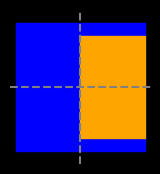

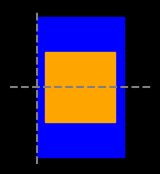

<Axes: >

In [59]:
poly_a = structures.structures[1].get_slice(0).merge_regions()
poly_b = structures.structures[2].get_slice(0).merge_regions()
poly_c = structures.structures[3].get_slice(0).merge_regions()
plot_ab(poly_a, poly_b)
plot_ab(poly_b, poly_c)

#### Sphere in Sphere in Sphere
- Hollow spheres with an inner sphere and second structure inside the inner sphere.

![Sphere in Sphere in Sphere](<../../Images/FreeCAD Images/Sphere in Spheres in Shell.png>)

In [ ]:
def nested_spheres_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=16, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # Outside
    sphere12 = make_sphere(roi_num=1, radius=6, spacing=slice_spacing)
    hole10 = make_sphere(roi_num=1, radius=5, spacing=slice_spacing)
    sphere8 = make_sphere(roi_num=1, radius=4, spacing=slice_spacing)
    sphere8 = make_sphere(roi_num=1, radius=4, spacing=slice_spacing)
    sphere6 = make_sphere(roi_num=2, radius=3, spacing=slice_spacing)

    # combine the contours
    slice_data = body + sphere12 + hole10 + sphere8 + sphere6
    return slice_data
